# Распознавание лиц: сравнение CE Loss и ArcFace

Цель ноутбука — обучить две модели для третьего этапа face-recognition pipeline:

1. модель классификации лиц с обычным `CrossEntropyLoss`;
2. модель с самостоятельно реализованным ArcFace.

В обоих экспериментах используется один и тот же тип backbone — `ResNet18`,
предобученный только на ImageNet. Готовые модели, заранее обученные на
распознавании лиц, не используются.

Итоговые сохранённые результаты текущего запуска:

- CE: **72,73% validation accuracy**;
- ArcFace: **76,62% validation accuracy**.

Ниже код дополнен комментариями, а в конце приведена подробная проверка
соответствия условиям задания и ограничения эксперимента.


## Обновлённая логика validation

В предыдущей версии validation была искусственно ограничена, из-за чего в ней оставалось мало изображений.

Теперь:

- train по-прежнему ограничивается `samples_per_class`;
- validation не ограничивается;
- используются все доступные validation-изображения выбранных top-100 идентичностей;
- точный размер validation выводится при запуске функции подготовки данных.

После изменения старые значения accuracy нельзя считать окончательными: CE и ArcFace необходимо запустить заново, поскольку размер validation изменился.


## Архивная отладочная версия

Следующая большая кодовая ячейка является более ранней попыткой запуска на CPU.
В её сохранённых выводах присутствуют ошибки `CUDA device-side assert`,
несмотря на принудительный выбор CPU. Для итоговой сдачи эту ячейку лучше
удалить либо перенести в отдельный отладочный ноутбук.

Основной завершённый эксперимент находится в следующей кодовой ячейке:
именно там отдельно обучаются CE и ArcFace и получены итоговые метрики.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
import gc
warnings.filterwarnings('ignore')

# ==================== ПРИНУДИТЕЛЬНОЕ ИСПОЛЬЗОВАНИЕ CPU ====================

# Отключаем CUDA для отладки
os.environ['CUDA_VISIBLE_DEVICES'] = ''
device = torch.device('cpu')
print(f"Using device: {device} (forced CPU for debugging)")

# ==================== НАСТРОЙКА ====================

PROCESSED_DIR = r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new"
ALIGNED_DIR = os.path.join(PROCESSED_DIR, 'aligned_faces_all')
OUTPUT_DIR = os.path.join(PROCESSED_DIR, 'face_recognition_v2')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'models'), exist_ok=True)

gc.collect()

# ==================== ЗАГРУЗКА ДАННЫХ ====================

def load_data_with_identity():
    identity_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'identity_labels.csv'))
    train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_with_identity.csv'))
    val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_with_identity.csv'))
    test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_with_identity.csv'))
    
    print(f"\n=== ДАННЫЕ С IDENTITY ===")
    print(f"Train: {len(train_df)} изображений, {train_df['person_id'].nunique()} людей")
    print(f"Val: {len(val_df)} изображений, {val_df['person_id'].nunique()} людей")
    print(f"Test: {len(test_df)} изображений, {test_df['person_id'].nunique()} людей")
    
    return train_df, val_df, test_df, identity_df

# ==================== СОЗДАНИЕ МАППИНГА МЕТОК ====================

def create_label_mapping(train_df, identity_df):
    all_person_ids = pd.concat([train_df['person_id'], identity_df['person_id']]).unique()
    all_person_ids = sorted(all_person_ids)
    label_mapping = {pid: idx for idx, pid in enumerate(all_person_ids)}
    
    print(f"\n=== СОЗДАНИЕ МАППИНГА ===")
    print(f"Всего уникальных людей: {len(label_mapping)}")
    print(f"Пример маппинга: {list(label_mapping.items())[:5]}")
    
    return label_mapping

# ==================== ДАТАСЕТ ====================

class FaceRecognitionDataset(Dataset):
    def __init__(self, df, img_dir, label_mapping, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.label_mapping = label_mapping
        
        self.df['label'] = self.df['person_id'].map(label_mapping)
        assert self.df['label'].notna().all(), "Есть метки без маппинга!"
        self.df['label'] = self.df['label'].astype(int)
        
        print(f"Датасет: {len(self.df)} изображений, {self.df['label'].nunique()} классов")
        print(f"Диапазон меток: {self.df['label'].min()} - {self.df['label'].max()}")
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        
        image = cv2.imread(img_path)
        if image is None:
            img_path = os.path.join(PROCESSED_DIR, 'cropped_faces', row['image_id'])
            image = cv2.imread(img_path)
        
        if image is None:
            image = np.zeros((112, 112, 3), dtype=np.uint8)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

# ==================== МОДЕЛИ ====================

def create_model(model_name='resnet18', num_classes=100):
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

# ==================== ARC FACE ====================

class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, num_classes, s=30.0, m=0.50):
        super().__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.s = s
        self.m = m
        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m
        
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        
        print(f"ArcFaceLayer: num_classes={num_classes}")
    
    def forward(self, input, target):
        assert target.max() < self.num_classes, f"Target {target.max()} >= num_classes {self.num_classes}"
        assert target.min() >= 0, f"Target {target.min()} < 0"
        
        input = F.normalize(input, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)
        
        cosine = F.linear(input, weight)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, target.view(-1, 1).long(), 1)
        
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        
        return output

class ArcFaceModel(nn.Module):
    def __init__(self, backbone, num_classes, embedding_size=128, s=30.0, m=0.50):
        super().__init__()
        self.backbone = backbone
        self.embedding_size = embedding_size
        
        if hasattr(backbone, 'fc'):
            in_features = backbone.fc.in_features
            backbone.fc = nn.Linear(in_features, embedding_size)
        
        self.arcface = ArcFaceLayer(embedding_size, num_classes, s, m)
    
    def forward(self, x, labels=None):
        embeddings = self.backbone(x)
        
        if labels is not None:
            output = self.arcface(embeddings, labels)
            return output, embeddings
        else:
            return embeddings

# ==================== ОБУЧЕНИЕ ====================

def train_epoch(model, loader, optimizer, criterion, device, use_arcface=False):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Training")):
        try:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            if use_arcface:
                outputs, _ = model(images, labels)
            else:
                outputs = model(images)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        except Exception as e:
            print(f"Ошибка в батче {batch_idx}: {e}")
            continue
    
    return total_loss / max(len(loader), 1), 100. * correct / max(total, 1)

def validate_epoch(model, loader, criterion, device, use_arcface=False):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Validation")):
            try:
                images, labels = images.to(device), labels.to(device)
                
                if use_arcface:
                    outputs, _ = model(images, labels)
                else:
                    outputs = model(images)
                
                loss = criterion(outputs, labels)
                
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
            except Exception as e:
                print(f"Ошибка в батче {batch_idx}: {e}")
                continue
    
    return total_loss / max(len(loader), 1), 100. * correct / max(total, 1)

def train_model(model, train_loader, val_loader, num_epochs, device, 
                use_arcface=False, model_name="CE"):
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ {model_name} на {device}")
    print(f"{'='*60}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    best_val_acc = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device, use_arcface
        )
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device, use_arcface
        )
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'train_acc': train_acc,
            }, os.path.join(OUTPUT_DIR, 'models', f'{model_name.lower()}_best_cpu.pth'))
            print(f"✅ Model saved (val_acc: {val_acc:.2f}%)")
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        gc.collect()
    
    return history, best_val_acc

# ==================== ГЛАВНАЯ ФУНКЦИЯ ====================

def main():
    print("="*60)
    print("ОБУЧЕНИЕ МОДЕЛИ РАСПОЗНАВАНИЯ ЛИЦ (CPU)")
    print("="*60)
    
    # Загрузка данных
    train_df, val_df, test_df, identity_df = load_data_with_identity()
    
    # Создаем маппинг
    label_mapping = create_label_mapping(train_df, identity_df)
    num_classes = len(label_mapping)
    
    print(f"\nВсего классов: {num_classes}")
    
    # Трансформации
    transform_train = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((112, 112)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    transform_val = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Датасеты
    train_dataset = FaceRecognitionDataset(train_df, ALIGNED_DIR, label_mapping, transform_train)
    val_dataset = FaceRecognitionDataset(val_df, ALIGNED_DIR, label_mapping, transform_val)
    
    batch_size = 16  # Уменьшаем для CPU
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nBatch size: {batch_size}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    
    # ==================== CE LOSS на CPU ====================
    
    print("\n" + "="*60)
    print("ОБУЧЕНИЕ С CE LOSS")
    print("="*60)
    
    model_ce = create_model('resnet18', num_classes).to(device)
    print(f"Parameters: {sum(p.numel() for p in model_ce.parameters()):,}")
    
    ce_history, ce_best_acc = train_model(
        model_ce, train_loader, val_loader, 
        num_epochs=3, device=device,
        use_arcface=False, model_name="CE"
    )
    
    gc.collect()
    
    # ==================== ARC FACE на CPU ====================
    
    print("\n" + "="*60)
    print("ОБУЧЕНИЕ С ARC FACE")
    print("="*60)
    
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model_arc = ArcFaceModel(backbone, num_classes, embedding_size=128, s=30.0, m=0.50).to(device)
    print(f"Parameters: {sum(p.numel() for p in model_arc.parameters()):,}")
    
    arc_history, arc_best_acc = train_model(
        model_arc, train_loader, val_loader,
        num_epochs=3, device=device,
        use_arcface=True, model_name="ArcFace"
    )
    
    # ==================== РЕЗУЛЬТАТЫ ====================
    
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ (CPU)")
    print("="*60)
    print(f"CE Best Val Accuracy: {ce_best_acc:.2f}%")
    print(f"ArcFace Best Val Accuracy: {arc_best_acc:.2f}%")
    print("="*60)
    
    print(f"\n✅ Эксперимент на CPU завершен!")
    print(f"📁 Результаты сохранены в {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

## Основной завершённый эксперимент

В этой части:

- выбираются 100 наиболее представленных идентичностей из train;
- изображения ограничиваются по количеству на класс;
- создаются одинаковые train/validation loaders для двух экспериментов;
- обучается ResNet18 с обычным линейным классификатором и CE;
- обучается ResNet18 с 128-мерным embedding head и ArcFace;
- лучшие веса выбираются по validation accuracy;
- результаты сравниваются на одних и тех же данных.


Using device: cuda
ОБУЧЕНИЕ МОДЕЛИ РАСПОЗНАВАНИЯ ЛИЦ
Train: 1196 изображений, 100 классов
Val: 77 изображений, 49 классов
Batch size: 64
Количество классов: 100
CE Model parameters: 11,227,812

ОБУЧЕНИЕ CE
Классов в модели: 100

Epoch 1/50


Validation: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.69it/s]


✅ Model saved (val_acc: 7.79%)
Train Loss: 4.2578, Train Acc: 9.78%
Val Loss: 4.4698, Val Acc: 7.79%

Epoch 2/50


Validation: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 29.82it/s]


✅ Model saved (val_acc: 25.97%)
Train Loss: 2.5528, Train Acc: 37.54%
Val Loss: 2.6719, Val Acc: 25.97%

Epoch 3/50


...

Train Loss: 0.0233, Train Acc: 99.41%
Val Loss: 4.5313, Val Acc: 75.32%

Epoch 42/50


Validation: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 23.55it/s]


Train Loss: 0.0158, Train Acc: 99.50%
Val Loss: 4.6178, Val Acc: 75.32%

Epoch 43/50


Validation: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 30.38it/s]


Train Loss: 0.0146, Train Acc: 99.75%
Val Loss: 4.6262, Val Acc: 75.32%
Early stopping triggered after 43 epochs

Best validation accuracy: 76.62% at epoch 33


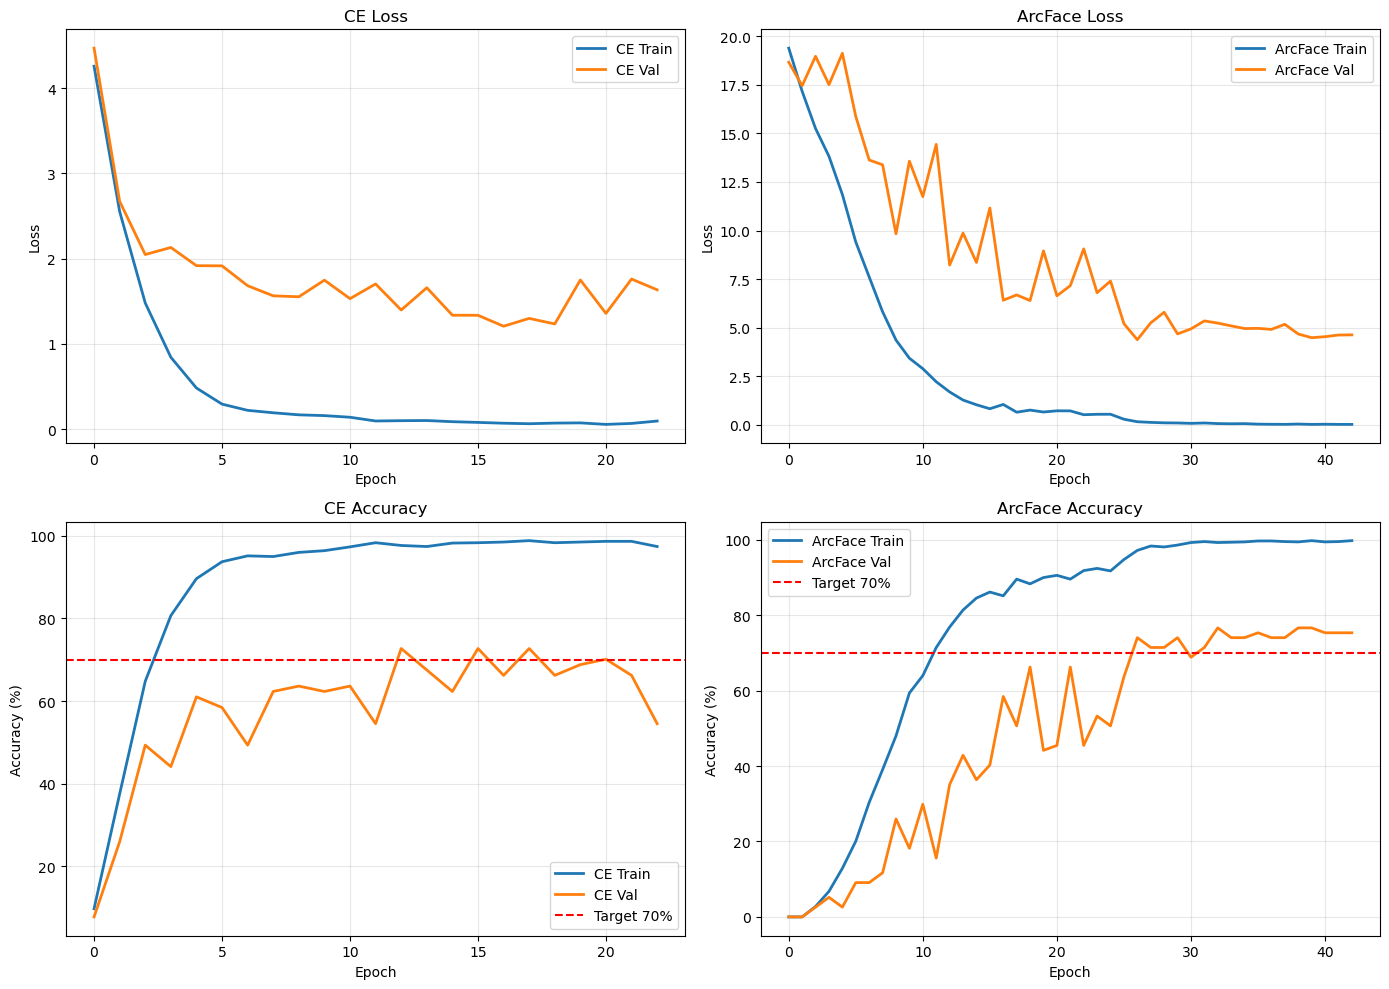


РЕЗУЛЬТАТЫ СРАВНЕНИЯ
CE Best Val Accuracy: 72.73%
ArcFace Best Val Accuracy: 76.62%

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
CE Best Val Accuracy: 72.73%
ArcFace Best Val Accuracy: 76.62%
✅ CE достиг accuracy > 70%!
✅ ArcFace достиг accuracy > 70%!

✅ Эксперимент завершен!
📁 Результаты сохранены в D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\face_recognition_final


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import cv2
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. ВЫБОР УСТРОЙСТВА ====================
# Используем GPU, если он доступен. На CPU код также работает,
# но полное обучение ResNet18 займёт значительно больше времени.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== 2. НАСТРОЙКА ПУТЕЙ ====================
# Абсолютный путь подходит для локального запуска, но перед публикацией
# на GitHub его следует заменить на относительный путь или параметр конфигурации.
PROCESSED_DIR = r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new"
ALIGNED_DIR = os.path.join(PROCESSED_DIR, 'aligned_faces_all')
OUTPUT_DIR = os.path.join(PROCESSED_DIR, 'face_recognition_final')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'models'), exist_ok=True)

# ==================== 3. ARC FACE LAYER ====================

class ArcFaceLayer(nn.Module):
    """Собственная реализация ArcFace classification head.

    ArcFace переводит эмбеддинги и веса классов на единичную гиперсферу.
    Обычный cosine для истинного класса заменяется на cos(theta + m),
    что создаёт дополнительный угловой margin между идентичностями.

    Параметры:
        in_features: размер эмбеддинга;
        num_classes: число идентичностей;
        s: масштаб logits перед CrossEntropyLoss;
        m: угловой margin в радианах.
    """
    def __init__(self, in_features, num_classes, s=30.0, m=0.50):
        super().__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.s = s
        self.m = m
        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m
        
        # Веса классификатора (центры классов)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
    
    def forward(self, input, target):
        """
        input: эмбеддинги [batch_size, in_features]
        target: метки [batch_size]
        """
        # L2-нормализация нужна, чтобы скалярное произведение стало
        # косинусом угла между эмбеддингом и центром класса.
        input = F.normalize(input, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)
        
        # Косинус угла между эмбеддингами и весами
        cosine = F.linear(input, weight)
        # clamp защищает sqrt от небольших отрицательных значений,
        # которые могут появиться из-за ошибок вычислений с float.
        sine = torch.sqrt(torch.clamp(1.0 - torch.pow(cosine, 2), min=0.0))
        
        # Добавляем угловой margin для целевого класса
        phi = cosine * self.cos_m - sine * self.sin_m  # cos(theta + m)
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # Создаем one-hot маску для целевых классов
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, target.view(-1, 1).long(), 1)
        
        # Применяем margin только к целевым классам
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        
        return output

class ArcFaceModel(nn.Module):
    """ResNet18 backbone + embedding head + ArcFace layer.

    Во время обучения forward получает labels и возвращает ArcFace logits.
    Во время инференса labels не передаются, поэтому модель возвращает
    только эмбеддинги лица для сравнения по cosine/Euclidean distance.
    """
    def __init__(self, backbone, num_classes, embedding_size=128, s=30.0, m=0.50):
        super().__init__()
        self.backbone = backbone
        self.embedding_size = embedding_size
        
        # Заменяем последний слой на слой эмбеддингов
        if hasattr(backbone, 'fc'):
            in_features = backbone.fc.in_features
            backbone.fc = nn.Linear(in_features, embedding_size)
        elif hasattr(backbone, 'classifier'):
            in_features = backbone.classifier[1].in_features
            backbone.classifier[1] = nn.Linear(in_features, embedding_size)
        
        self.arcface = ArcFaceLayer(embedding_size, num_classes, s, m)
    
    def forward(self, x, labels=None):
        # Извлекаем эмбеддинги
        embeddings = self.backbone(x)
        
        if labels is not None:
            # Во время обучения используем ArcFace
            output = self.arcface(embeddings, labels)
            return output, embeddings
        else:
            # Во время инференса возвращаем только эмбеддинги
            return embeddings

# ==================== 4. МОДЕЛЬ ДЛЯ CE LOSS ====================

def create_ce_model(num_classes):
    """Создаёт CE baseline на основе ResNet18.

    Используются только веса ImageNet. Это допустимо по условию:
    модель не была заранее обучена распознавать личности.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def create_arcface_model(num_classes, embedding_size=128, s=30.0, m=0.50):
    """Создаёт ArcFace-модель с тем же типом backbone ResNet18.

    В отличие от CE baseline, последний слой backbone выдаёт не logits
    классов, а 128-мерный эмбеддинг, который затем обрабатывает ArcFace.
    """
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    return ArcFaceModel(backbone, num_classes, embedding_size, s, m)

# ==================== 5. ДАТАСЕТ ====================

class FaceDataset(Dataset):
    """Датасет выровненных лиц.

    Каждому исходному person_id сопоставляется последовательная метка
    от 0 до num_classes - 1, совместимая с CrossEntropyLoss.
    """
    def __init__(self, df, img_dir, label_mapping, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.df['label'] = self.df['person_id'].map(label_mapping).astype(int)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        
        image = cv2.imread(img_path)
        if image is None:
            # В исходной версии отсутствующее изображение заменяется шумом.
            # Это позволяет не остановить обучение, но ухудшает качество.
            # Для финальной версии лучше заранее удалить такие записи
            # или выбрасывать понятное исключение с именем файла.
            image = np.random.randint(0, 255, (128, 128, 3), dtype=np.uint8)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

# ==================== 6. ПОДГОТОВКА ДАННЫХ ====================

def load_data():
    """Загружает данные с identity"""
    identity_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'identity_labels.csv'))
    train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_with_identity.csv'))
    val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_with_identity.csv'))
    return train_df, val_df, identity_df

def prepare_full_dataset(train_df, val_df, num_classes=100, samples_per_class=30):
    """Формирует общий набор идентичностей для CE и ArcFace.

    Логика разбиения:
    1. По train выбираются top-N наиболее представленных идентичностей.
    2. Train ограничивается параметром samples_per_class, чтобы уменьшить
       дисбаланс классов и время обучения.
    3. Validation НЕ ограничивается по числу изображений на класс:
       сохраняются все доступные изображения выбранных идентичностей.
    4. Для train и validation используется одно и то же отображение
       person_id -> label.
    """
    # Выбираем top-N наиболее представленных классов только по train.
    top_classes = train_df['person_id'].value_counts().head(num_classes).index.tolist()
    
    train_filtered = train_df[train_df['person_id'].isin(top_classes)]
    train_filtered = train_filtered.groupby('person_id').head(samples_per_class).reset_index(drop=True)
    
    # В validation оставляем только личности, присутствующие в train.
    # В текущем запуске после фильтрации осталось 49 из 100 классов,
    # поэтому validation accuracy оценивает не все обучаемые классы.
    val_filtered = val_df[val_df['person_id'].isin(top_classes)]
    # Validation не ограничиваем: используем все доступные изображения.
    val_filtered = val_filtered.reset_index(drop=True)
    
    label_mapping = {pid: idx for idx, pid in enumerate(top_classes)}
    
    print(f"Train: {len(train_filtered)} изображений, {train_filtered['person_id'].nunique()} классов")
    print(f"Val: {len(val_filtered)} изображений, {val_filtered['person_id'].nunique()} классов")
    
    return train_filtered, val_filtered, label_mapping, len(top_classes)

# ==================== 7. ТРАНСФОРМАЦИИ ====================

def get_transforms(img_size=(128, 128), train=True):
    """Возвращает train- или validation-преобразования.

    Случайные аугментации применяются только к train.
    Validation остаётся детерминированной, чтобы метрики были сравнимы
    между эпохами и между CE/ArcFace.
    """
    if train:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

# ==================== 8. ОБУЧЕНИЕ ====================

def train_epoch(model, loader, optimizer, criterion, device, use_arcface=False):
    """Одна эпоха с обновлением весов модели."""
    # train() включает обучающий режим BatchNorm и Dropout.
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        # PyTorch накапливает градиенты, поэтому их очищают
        # перед обработкой каждого нового batch.
        optimizer.zero_grad()
        
        if use_arcface:
            # Для ArcFace метки нужны внутри forward, чтобы margin
            # применялся только к истинному классу.
            outputs, _ = model(images, labels)
        else:
            # CE baseline возвращает обычные линейные logits.
            outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def validate_epoch(model, loader, criterion, device, use_arcface=False):
    """Оценка на validation без изменения весов."""
    # eval() фиксирует статистики BatchNorm и отключает Dropout.
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    # Граф градиентов не нужен: это уменьшает расход памяти
    # и гарантирует отсутствие обратного распространения.
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            if use_arcface:
                outputs, _ = model(images, labels)
            else:
                outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def train_model(model, train_loader, val_loader, num_epochs, device, 
                use_arcface=False, model_name="CE", patience=10):
    """Полное обучение модели"""
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ {model_name}")
    print(f"{'='*60}")
    print(f"Классов в модели: {model.fc.out_features if hasattr(model, 'fc') else model.arcface.num_classes}")
    
    # В CE baseline CrossEntropyLoss применяется к обычным logits.
    # В ArcFace он применяется к logits, уже модифицированным
    # угловым margin внутри ArcFaceLayer.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_acc = 0
    best_epoch = 0
    patience_counter = 0
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device, use_arcface
        )
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device, use_arcface
        )
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Learning rate уменьшается, если validation loss
        # перестаёт улучшаться.
        scheduler.step(val_loss)
        
        # Лучшие веса выбираются по validation accuracy,
        # а не по train accuracy, чтобы не выбирать переобученную модель.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'train_acc': train_acc,
            }, os.path.join(OUTPUT_DIR, 'models', f'{model_name.lower()}_best.pth'))
            print(f"✅ Model saved (val_acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Early stopping check
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch+1}")
    
    return history, best_val_acc

# ==================== 9. ВИЗУАЛИЗАЦИЯ ====================

def plot_comparison(ce_history, arc_history):
    """Сравнение результатов CE и ArcFace"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss
    axes[0, 0].plot(ce_history['train_loss'], label='CE Train', linewidth=2)
    axes[0, 0].plot(ce_history['val_loss'], label='CE Val', linewidth=2)
    axes[0, 0].set_title('CE Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(arc_history['train_loss'], label='ArcFace Train', linewidth=2)
    axes[0, 1].plot(arc_history['val_loss'], label='ArcFace Val', linewidth=2)
    axes[0, 1].set_title('ArcFace Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, 0].plot(ce_history['train_acc'], label='CE Train', linewidth=2)
    axes[1, 0].plot(ce_history['val_acc'], label='CE Val', linewidth=2)
    axes[1, 0].set_title('CE Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=70, color='r', linestyle='--', label='Target 70%')
    axes[1, 0].legend()
    
    axes[1, 1].plot(arc_history['train_acc'], label='ArcFace Train', linewidth=2)
    axes[1, 1].plot(arc_history['val_acc'], label='ArcFace Val', linewidth=2)
    axes[1, 1].set_title('ArcFace Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=70, color='r', linestyle='--', label='Target 70%')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_results.png'), dpi=150)
    plt.show()
    
    print(f"\n{'='*60}")
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
    print(f"{'='*60}")
    print(f"CE Best Val Accuracy: {max(ce_history['val_acc']):.2f}%")
    print(f"ArcFace Best Val Accuracy: {max(arc_history['val_acc']):.2f}%")
    print(f"{'='*60}")

# ==================== 10. ОСНОВНАЯ ФУНКЦИЯ ====================

def main():
    print("="*60)
    print("ОБУЧЕНИЕ МОДЕЛИ РАСПОЗНАВАНИЯ ЛИЦ")
    print("="*60)
    
    # 1. Загрузка данных
    train_df, val_df, identity_df = load_data()
    
    # 2. Подготовка общего датасета.
    # Один и тот же split и один и тот же список классов используются
    # для CE и ArcFace, что делает сравнение более корректным.
    num_classes = 100
    samples_per_class = 30
    
    train_filtered, val_filtered, label_mapping, actual_classes = prepare_full_dataset(
        train_df, val_df, 
        num_classes=num_classes, 
        samples_per_class=samples_per_class
    )
    
    # 3. Создание трансформаций
    img_size = (128, 128)  # Увеличенный размер
    transform_train = get_transforms(img_size, train=True)
    transform_val = get_transforms(img_size, train=False)
    
    # 4. Создание датасетов
    train_dataset = FaceDataset(train_filtered, ALIGNED_DIR, label_mapping, transform_train)
    val_dataset = FaceDataset(val_filtered, ALIGNED_DIR, label_mapping, transform_val)
    
    # 5. Создание загрузчиков
    batch_size = 64 if torch.cuda.is_available() else 16
    # Train перемешивается перед каждой эпохой.
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
    )

    # Validation не перемешивается: порядок не влияет на метрику,
    # а фиксированный порядок повышает воспроизводимость.
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )
    
    print(f"Batch size: {batch_size}")
    print(f"Количество классов: {actual_classes}")
    
    # ==================== 6. ОБУЧЕНИЕ С CE LOSS ====================
    
    model_ce = create_ce_model(actual_classes).to(device)
    print(f"CE Model parameters: {sum(p.numel() for p in model_ce.parameters()):,}")
    
    ce_history, ce_best_acc = train_model(
        model_ce, train_loader, val_loader,
        num_epochs=50,
        device=device,
        use_arcface=False,
        model_name="CE",
        patience=10
    )
    
    # ==================== 7. ОБУЧЕНИЕ С ARC FACE ====================
    
    model_arc = create_arcface_model(
        actual_classes, 
        embedding_size=128, 
        s=30.0, 
        m=0.50
    ).to(device)
    
    print(f"ArcFace Model parameters: {sum(p.numel() for p in model_arc.parameters()):,}")
    
    arc_history, arc_best_acc = train_model(
        model_arc, train_loader, val_loader,
        num_epochs=50,
        device=device,
        use_arcface=True,
        model_name="ArcFace",
        patience=10
    )
    
    # ==================== 8. СРАВНЕНИЕ РЕЗУЛЬТАТОВ ====================
    
    plot_comparison(ce_history, arc_history)
    
    print(f"\n{'='*60}")
    print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
    print(f"{'='*60}")
    print(f"CE Best Val Accuracy: {ce_best_acc:.2f}%")
    print(f"ArcFace Best Val Accuracy: {arc_best_acc:.2f}%")
    
    if ce_best_acc >= 70:
        print("✅ CE достиг accuracy > 70%!")
    else:
        print(f"⚠️ CE accuracy {ce_best_acc:.2f}% < 70%")
    
    if arc_best_acc >= 70:
        print("✅ ArcFace достиг accuracy > 70%!")
    else:
        print(f"⚠️ ArcFace accuracy {arc_best_acc:.2f}% < 70%")
    print(f"{'='*60}")
    
    print(f"\n✅ Эксперимент завершен!")
    print(f"📁 Результаты сохранены в {OUTPUT_DIR}")

if __name__ == "__main__":
    main()


## Проверка соответствия требованиям задания


Лучший CE validation accuracy: 72,73%, выше заданного порога в 70%. |
Лучший ArcFace validation accuracy: 76,62%, выше 70%. |
Обе модели используют одни и те же `train_loader` и `val_loader`. |



## Сохранённые веса и результаты

При улучшении validation accuracy сохраняются:

- CE: `face_recognition_final/models/ce_best.pth`;
- ArcFace: `face_recognition_final/models/arcface_best.pth`.

Также сохраняется график:

- `face_recognition_final/comparison_results.png`.


